# 1

In [1]:
from pydantic import BaseModel , EmailStr, AnyUrl,Field
from typing import List ,Dict ,Optional ,Annotated

class Patient(BaseModel):
    
    name:Annotated[str,Field(max_length=50,title="name of the patient",description="Give the name of the patient in less than 50 chars",examples=['Hanu','Aravind'])]
    email: EmailStr
    linkedin_url:AnyUrl
    age:int=Field(gt=10,lt=100)
    weight:Annotated[float,Field(gt=0,strict=True)]
    married:Annotated[bool,Field(default=None,description="Is the patient married or not ")]
    allergies:Annotated[Optional[List[str]],Field(default=None,max_length=5)]
    contact_details:Dict[str,str]
    
def updated_patient_data(patient:Patient):
    
    print(patient.name)
    print(patient.age)
    print(patient.allergies)
    print(patient.married)
    print('updated')
    
patient_info={'name':'Nikhil', 'email':'abc@gmail.com', 'linkedin_url':'http://linkedin.com/1322', 'age': '21', 'weight': 57,'contact_details':{'phone':'2353462'}}


patient1=Patient(**patient_info)
updated_patient_data(patient1)
print(patient1)

Nikhil
21
None
None
updated
name='Nikhil' email='abc@gmail.com' linkedin_url=AnyUrl('http://linkedin.com/1322') age=21 weight=57.0 married=None allergies=None contact_details={'phone': '2353462'}


# 2 Field Validator 

In [7]:
from pydantic import BaseModel ,EmailStr,AnyUrl,Field ,field_validator
from typing import List,Dict,Optional,Annotated

class Patient(BaseModel):
    
    name:str
    email:EmailStr
    age:int
    weight:float
    married:bool
    allergies:List[str]
    contact_details:Dict[str,str]
    
    @field_validator('email')
    @classmethod
    def email_validator(cls,value):
        
        valid_domains =['hdfc.com','icici.com']
        
        domain_name=value.split('@')[-1]
        
        if domain_name not in valid_domains:
            raise ValueError('Not a valid domain')
        return value
      
    @field_validator('name')
    @classmethod
    def transform_name(cls, value):
        return value.upper()
    
    @field_validator('age', mode='after') # this mode = after makes sure that age value got here after type conversion
    @classmethod
    def validate_age(cls, value):
        if 0 < value < 100:
            return value
        else:
            raise ValueError('Age should be in between 0 and 100')

def updated_patient_data(patient:Patient):
    print(patient.name)
    print(patient.age)
    print(patient.allergies)
    print(patient.married)
    print('updated')
    
patient_info={'name':'Nikhil', 'email':'abc@icici.com',  'age': '21', 'weight': 57,'married':False,'allergies': ['pollen', 'dust'],'contact_details':{'phone':'2353462'}}


patient1=Patient(**patient_info)
updated_patient_data(patient1)
print(patient1)      
   
    

NIKHIL
21
['pollen', 'dust']
False
updated
name='NIKHIL' email='abc@icici.com' age=21 weight=57.0 married=False allergies=['pollen', 'dust'] contact_details={'phone': '2353462'}


# 3  model validator

# Pydantic model_validator mode after

## What it is

model_validator with mode set to after is used to validate the entire model after all individual fields have already been validated and the model object is created.

---

## Why it is needed

* Field validation only checks individual fields
* Sometimes validation depends on multiple fields
* mode after allows using final validated values together

---

## How it works

1. Input data is received
2. Each field is validated
3. Model object is created
4. model_validator with mode after runs

---

## Example

```python
from pydantic import BaseModel, model_validator

class Patient(BaseModel):
    weight: float
    height: float

    @model_validator(mode='after')
    def check_bmi(self):
        bmi = self.weight / (self.height ** 2)

        if bmi < 10:
            raise ValueError("BMI too low")

        return self
```
### mode ='before'
``` 
@model_validator(mode='before')
def preprocess(cls, values):
    values['name'] = values['name'].upper()
    return values ```
---

## Key Points

* Runs after full validation
* Uses self (model object)
* Best for cross field validation
* Ensures final data consistency

---

## Difference from before

| Mode   | When it runs      | Input           |
| ------ | ----------------- | --------------- |
| before | Before validation | raw input data  |
| after  | After validation  | validated model |

---

## Summary

model_validator with mode after is used when validation depends on multiple fields. It runs after the model is fully created, making it safe to access all validated values and apply complex validation logic.


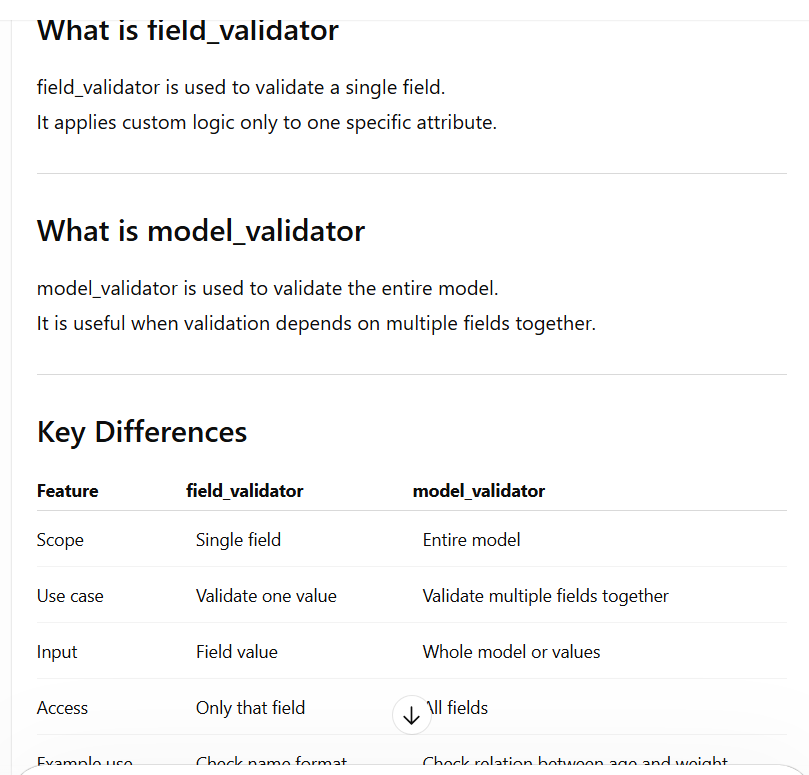

In [17]:
from pydantic import BaseModel, EmailStr, model_validator
from typing import List, Dict

class Patient(BaseModel):
    name: str
    email: EmailStr
    age: int
    weight: float
    married: bool
    allergies: List[str]
    contact_details: Dict[str, str]

    @model_validator(mode='after')
    def validation_emergency_contact(self):
        if self.age>60 and 'emergency' not in self.contact_details:
            raise ValueError('Patient older than 60 must have an emergency contct')
        return self
    
def update_patient_data(patient: Patient):
    print(patient.name)
    print(patient.age)
    print(patient.allergies)
    print(patient.married)
    print('updated')
    

patient_info = {
    'name': 'Thanuja',
    'email': 'abc@icici.com',
    'age': 23,
    'weight': 57,
    'married': False,
    'allergies': ['pollen', 'dust'],
    'contact_details': {'phone': '2353462', 'emergency': '235236'}
}

patient1 = Patient(**patient_info)
update_patient_data(patient1)  

Thanuja
23
['pollen', 'dust']
False
updated


✅ Final Flow Summary Diagram
User Code: Patient(**data)
       │
       ▼
Pydantic: Validate fields (types, constraints)
       │
       ▼
Pydantic: Run @model_validator(mode='after')
       │
       ├── Pass → Return model instance
       └── Fail → Raise ValidationError
       │
       ▼
User Code: Receives validated Patient object

# 4 computed field 

In [18]:
from pydantic import BaseModel, EmailStr, computed_field
from typing import List, Dict

class Patient(BaseModel):

    name: str
    email: EmailStr
    age: int
    weight: float # kg
    height: float # mtr
    married: bool
    allergies: List[str]
    contact_details: Dict[str, str]

    @computed_field
    @property
    def bmi(self) -> float:
        bmi = round(self.weight/(self.height**2),2)
        return bmi



def update_patient_data(patient: Patient):

    print(patient.name)
    print(patient.age)
    print(patient.allergies)
    print(patient.married)
    print('BMI', patient.bmi)
    print('updated')

patient_info = {'name':'Thanuja', 'email':'abc@icici.com', 'age': '65', 'weight': 53, 'height': 1.72, 'married': False, 'allergies': ['pollen', 'dust'], 'contact_details':{'phone':'2353462', 'emergency':'235236'}}

patient1 = Patient(**patient_info) 

update_patient_data(patient1)

Thanuja
65
['pollen', 'dust']
False
BMI 17.92
updated


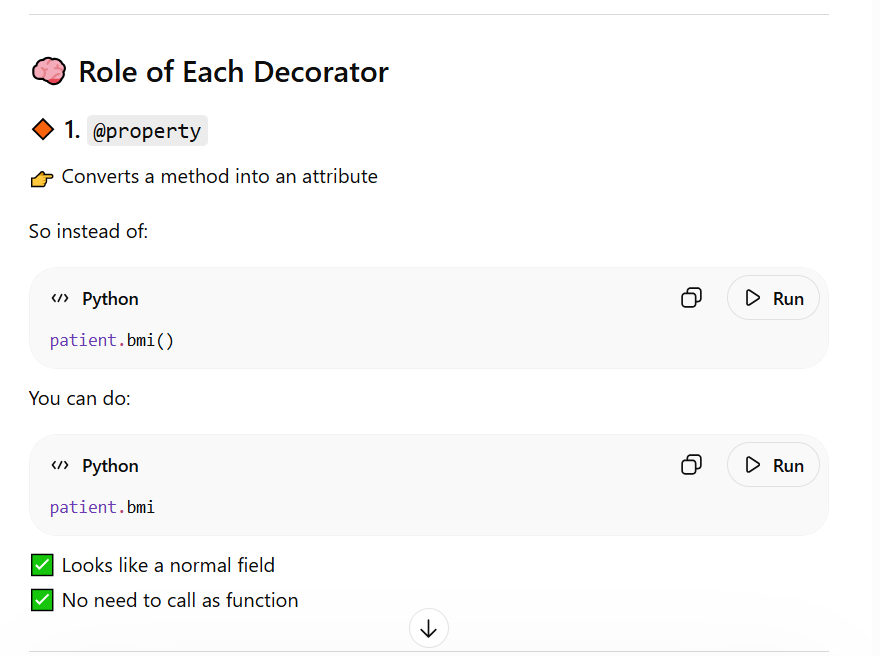
👉 @property → makes it behave like a field
👉 @computed_field → makes FastAPI include it in response
@property makes the method behave like an attribute, and @computed_field tells Pydantic to include that attribute in the output as a field.

#  nested and serialization

In [16]:
from pydantic import BaseModel
class Address(BaseModel):
    city:str
    state:str
    pin :str
    
class Patient(BaseModel):
    name:str
    gennder:str='Male'
    age:int
    address:Address
    
    
address_dict ={'city':'haryana','state':'thamil nadu','pin':'122001'}

address1 = Address(**address_dict)
patient_dict = {'name': 'nitish', 'age': 35, 'address': address1}

patient1 = Patient(**patient_dict)

temp1 = patient1.model_dump(exclude_unset=True) 
temp2 = patient1.model_dump_json()
print(temp1)
print("type of temp1 is ",type(temp1))
print(temp2)
print("type(temp2) is ",type(temp2))

{'name': 'nitish', 'age': 35, 'address': {'city': 'haryana', 'state': 'thamil nadu', 'pin': '122001'}}
type of temp1 is  <class 'dict'>
{"name":"nitish","gennder":"Male","age":35,"address":{"city":"haryana","state":"thamil nadu","pin":"122001"}}
type(temp2) is  <class 'str'>


| Feature       | model_dump()     | model_dump_json() |
| ------------- | ---------------- | ----------------- |
| Output type   | dict             | string (JSON)     |
| Use case      | Python logic     | API / network     |
| Readability   | Python format    | JSON format       |
| Nested models | dict inside dict | JSON inside JSON  |
